In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the clean CSV file
data_path = "./data/mexico-real-estate-combined-clean.csv" 

# Load the data
data = pd.read_csv(data_path)

# Verify the load
print(f"Dimensions: {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

Dimensions: 1736 rows and 6 columns.


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [2]:
# Calculate correlation between 'area_m2' and 'price_usd'
corr_price_area = (
    data["area_m2"]
    .corr(data["price_usd"])
)

print(f"The correlation between Area and Price is: {corr_price_area:.4f}")

The correlation between Area and Price is: 0.5855


In [3]:
# Select only numerical columns
# Compute the correlation matrix
corr_matrix = (
    data
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,lat,lon,area_m2,price_usd
lat,1.000000,-0.480231,0.082314,-0.085868
lon,-0.480231,1.000000,0.095522,0.032815
area_m2,0.082314,0.095522,1.000000,0.585518
price_usd,-0.085868,0.032815,0.585518,1.000000


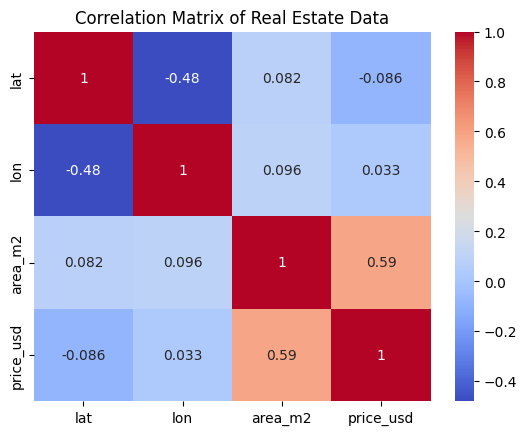

In [4]:
# Create a figure
fig, ax = plt.subplots()

# Create the heatmap using Seaborn
# annot=True adds the numbers to the boxes
# cmap="coolwarm" creates a nice Red (hot/positive) to Blue (cold/negative) spectrum
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix of Real Estate Data")
plt.show()

In [5]:
(
    data
    .head()
)

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [6]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]   
)

In [7]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .head() # <--to view top 5 rows
)

area_m2  price_usd
state                                             
Aguascalientes      area_m2    1.000000   0.873437
                    price_usd  0.873437   1.000000
Baja California     area_m2    1.000000   0.658334
                    price_usd  0.658334   1.000000
Baja California Sur area_m2    1.000000   0.880583

In [10]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .head(10) # <-- to only view the top 10 rows
)

state                         
Aguascalientes       area_m2      0.873437
                     price_usd    1.000000
Baja California      area_m2      0.658334
                     price_usd    1.000000
Baja California Sur  area_m2      0.880583
                     price_usd    1.000000
Campeche             area_m2      0.824161
                     price_usd    1.000000
Chiapas              area_m2      0.755961
                     price_usd    1.000000
Name: price_usd, dtype: float64

In [11]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
        .xs("price_usd", level=1)
    .head() #to only view the top 5 rows
)

state
Aguascalientes         1.0
Baja California        1.0
Baja California Sur    1.0
Campeche               1.0
Chiapas                1.0
Name: price_usd, dtype: float64

In [12]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .sort_values(ascending=False)
    .head() # <-- to view only the top 5 rows
)

state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64

In [13]:
# Calculate correlation by state

correlations_by_state = (
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()                          # Build correlation matrix per state
    .iloc[:, 1]                      # Keep only the price_usd column
    .xs("area_m2", level=1)          # Extract one correlation value per state
    .sort_values(ascending=False)    # Rank strongest to weakest
)

print(correlations_by_state.head(5))
print("\n price_usd and the bottom 5 price_usd\n")
print(correlations_by_state.tail(5))

state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64

 price_usd and the bottom 5 price_usd

state
Nuevo León                         0.578696
Veracruz de Ignacio de la Llave    0.567469
Distrito Federal                   0.410704
Tabasco                            0.241284
Oaxaca                            -1.000000
Name: price_usd, dtype: float64


In [17]:
# calculate correlation by property_type
correlations_by_prop = (
    data
    .groupby("property_type") # groupby '"property_type"'
    [["area_m2", "price_usd"]] # we select by the '"area_m2 and '"price_usd"' columns
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1) # extracts the '"area_m2"' correlation value from the inner index level. 
)
print(correlations_by_prop)

property_type
apartment    0.519021
house        0.719280
Name: price_usd, dtype: float64


In [18]:
# Create new column
df = (
    data
    .assign(price_per_m2 = lambda x: x["price_usd"] / x["area_m2"])
)

df.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


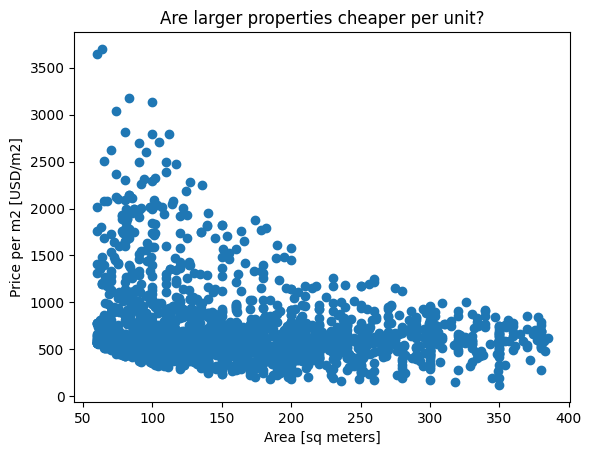

In [19]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(x=df["area_m2"], y=df["price_per_m2"],)

ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price per m2 [USD/m2]")

plt.show()